# Exploration Data Analyses

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### L'importer les bibliotheque necessaire

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/Datasets/E-commerce_Data/ecommerce_orders_dataset.csv", index_col=False)

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
df

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,London,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,603016,CUST006407,2026-12-31,2026,12,31,Thursday,4,28,Female,United Kingdom,London,Loyal,PROD00943,Home & Kitchen,Cookware,Nova,152.00,2,5,15.20,Yes,3.53,32.84,325.17,Bank Transfer,Mobile,Paid Ads,Standard,Standard,South,7,Delivered,No,4.4,4656.30,36.51,118.72,Winter,Yes,No
29996,615920,CUST003743,2026-12-31,2026,12,31,Thursday,4,49,Female,UAE,New York,Loyal,PROD00796,Sports,Fitness,Apex,66.48,3,15,29.92,Yes,6.72,22.83,199.07,Cash on Delivery,Mobile,Direct,Silver,Standard,Central,7,Delivered,No,4.6,3748.59,15.93,31.71,Winter,No,No
29997,603150,CUST005027,2026-12-31,2026,12,31,Thursday,4,41,Male,Australia,Sydney,Returning,PROD00468,Groceries,Beverages,Zenith,31.11,3,0,0.00,No,3.21,5.41,101.95,Credit Card,Mobile,Referral,Gold,Standard,Central,8,Shipped,No,4.1,1726.84,26.93,27.46,Winter,Yes,No
29998,626020,CUST008716,2026-12-31,2026,12,31,Thursday,4,38,Male,Canada,Paris,Returning,PROD00444,Home & Kitchen,Appliances,Nova,61.98,4,10,24.79,Yes,11.70,27.22,262.05,PayPal,Desktop,Social Media,Standard,Standard,East,3,Delivered,No,3.8,2519.08,11.30,29.61,Winter,Yes,No


In [5]:
datasets_info = pd.DataFrame({
    "Dataset": ["E-commerce Orders"],
    "Rows Count": [df.shape[0]],
    "Columns Count": [df.shape[1]]
})

datasets_info

,Dataset,Rows Count,Columns Count
0,E-commerce Orders,30000,41


In [6]:
data_dictionary = pd.read_csv("/content/drive/MyDrive/Datasets/E-commerce_Data/data_dictionary.csv")
data_dictionary

,Column,Description
0,Order_ID,Unique order identifier
1,Customer_ID,Unique customer identifier
2,Order_Date,Date when the order was placed
3,Year,Order year
4,Month,Order month
5,Day,Order day
6,Day_Of_Week,Day of the week
7,Quarter,Business quarter
8,Customer_Age,Customer age in years
9,Customer_Gender,Customer gender


In [7]:
all_rows = []

for col in df.columns:
  all_rows.append({
      "Column": col,
      "Dtype": str(df[col].dtype),
      "Non Null Count": df[col].count(),
      "Null Count": df[col].isna().sum(),
      "Unique Values": df[col].nunique()
  })
columns_df = pd.DataFrame(all_rows)

columns_df

,Column,Dtype,Non Null Count,Null Count,Unique Values
0,Order_ID,int64,30000,0,30000
1,Customer_ID,object,30000,0,8683
2,Order_Date,object,30000,0,1461
3,Year,int64,30000,0,4
4,Month,int64,30000,0,12
5,Day,int64,30000,0,31
6,Day_Of_Week,object,30000,0,7
7,Quarter,int64,30000,0,4
8,Customer_Age,int64,30000,0,58
9,Customer_Gender,object,30000,0,3


In [8]:
all_stats = []

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
  if col in ['Order_ID','Year','Month','Day','Quarter']:
    continue
  all_stats.append({
      "Column": col,
      "Count": df[col].count(),
      "Mean": df[col].mean(),
      "Std": df[col].std(),
      "Min": df[col].min(),
      "25%": df[col].quantile(0.25),
      "50%": df[col].median(),
      "75%": df[col].quantile(0.75),
      "Max": df[col].max()
  })
describe_df = pd.DataFrame(all_stats)

describe_df

,Column,Count,Mean,Std,Min,25%,50%,75%,Max
0,Customer_Age,30000,36.370300,11.315534,18.00,28.0000,36.000,44.0000,75.00
1,Unit_Price,30000,126.820148,172.675272,3.84,29.8800,60.670,128.5725,1940.00
2,Quantity,30000,3.080667,1.450412,1.00,2.0000,3.000,4.0000,11.00
3,Discount_Percent,30000,12.618667,11.085201,0.00,0.0000,10.000,20.0000,40.00
4,Discount_Amount,30000,49.432742,114.401634,0.00,0.0000,13.470,44.8225,2623.90
5,Shipping_Cost,30000,10.316779,5.890701,0.00,6.0200,9.000,14.2200,32.60
6,Tax_Amount,30000,29.143818,49.562251,0.26,5.2700,12.065,29.4425,1043.16
7,Order_Amount,30000,379.001466,585.405554,6.67,82.9475,171.030,388.1900,10314.27
8,Delivery_Days,30000,4.436667,2.349363,0.00,3.0000,4.000,6.0000,13.00
9,Review_Rating,30000,4.047990,0.686492,1.00,3.6000,4.100,4.6000,5.00


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Analyser les statistiques descriptives:
statis_desc = []
for var in df.select_dtypes(include='number').columns:
    if var in ['Order_ID','Year','Month','Day','Quarter']:
        continue
    statis_desc.append({
        'variable': var,
        'moyenne': df[var].mean(),
        'min': df[var].min(),
        '25%': df[var].quantile(0.25),
        'médiane(50%)': df[var].median(),   # ou df[var].median()
        '75%': df[var].quantile(0.75),
        'max': df[var].max(),
        'écart-type': df[var].std()
    })
statis_desc_df = pd.DataFrame(statis_desc)
statis_desc_df

,variable,moyenne,min,25%,médiane(50%),75%,max,écart-type
0,Customer_Age,36.370300,18.00,28.0000,36.000,44.0000,75.00,11.315534
1,Unit_Price,126.820148,3.84,29.8800,60.670,128.5725,1940.00,172.675272
2,Quantity,3.080667,1.00,2.0000,3.000,4.0000,11.00,1.450412
3,Discount_Percent,12.618667,0.00,0.0000,10.000,20.0000,40.00,11.085201
4,Discount_Amount,49.432742,0.00,0.0000,13.470,44.8225,2623.90,114.401634
5,Shipping_Cost,10.316779,0.00,6.0200,9.000,14.2200,32.60,5.890701
6,Tax_Amount,29.143818,0.26,5.2700,12.065,29.4425,1043.16,49.562251
7,Order_Amount,379.001466,6.67,82.9475,171.030,388.1900,10314.27,585.405554
8,Delivery_Days,4.436667,0.00,3.0000,4.000,6.0000,13.00,2.349363
9,Review_Rating,4.047990,1.00,3.6000,4.100,4.6000,5.00,0.686492


# ANALYSE TECHNIQUE DES DONNEES

### Performance des ventes

In [11]:
df.insert(loc=19, column='Total_revenue',
          value=df['Quantity'] * df['Unit_Price'])
df['Total_revenue']

,Total_revenue
0,55.32
1,46.58
2,186.54
3,273.18
4,99.44
...,...
29995,304.00
29996,199.44
29997,93.33
29998,247.92


## Analyse technique des variables metier

### ✔ Les types des variables

| Type de variable | Nombre de variables | Variables |
|------------------|:-------------------:|-----------|
| **Variables quantitatives continues** | **10** | Unit_Price, Discount_Percent, Discount_Amount, Total_revenue, Shipping_Cost, Tax_Amount, Order_Amount, Customer_Lifetime_Value, Profit_Margin_Percent, Profit_Amount |
| **Variables qualitatives nominales** | **18** | Customer_Gender, Country, City, Product_Category, Product_Subcategory, Brand, Payment_Method, Device_Type, Traffic_Source,Shipping_Method, Warehouse_Region, Order_Status, Day_Of_Week, Season, Coupon_Used, Returned, Holiday_Season, High_Value_Order |
| **Variables qualitatives ordinales** | **4** | Customer_Segment, Membership_Status, Quarter, Review_Rating |
| **Variables quantitatives discrètes** | **6** | Customer_Age, Quantity, Delivery_Days, Year, Month, Day |
| **Total** | **38** | 38 variables |

In [12]:
cols = ["Order_ID", "Year", "Month", "Day", "Quarter", "Customer_Age"]

df[cols] = df[cols].astype(str)

In [13]:
var_contenue = []
var_discret =[]
df_num = df.select_dtypes(include='number')
df_cat = df.select_dtypes(exclude='number')

for col in df_num:
    if col in ['Quantity','Delivery_Days', 'Review_Rating']:
        continue
    var_contenue.append(col)

for col in df_cat:
    if col in ["Order_ID", 'Customer_ID', 'Product_ID', 'Order_Date', "Year", "Month", "Day", "Quarter"]:
      continue
    var_discret.append(col)

In [14]:
df_num.dtypes

,0
Unit_Price,float64
Quantity,int64
Total_revenue,float64
Discount_Percent,int64
Discount_Amount,float64
Shipping_Cost,float64
Tax_Amount,float64
Order_Amount,float64
Delivery_Days,int64
Review_Rating,float64


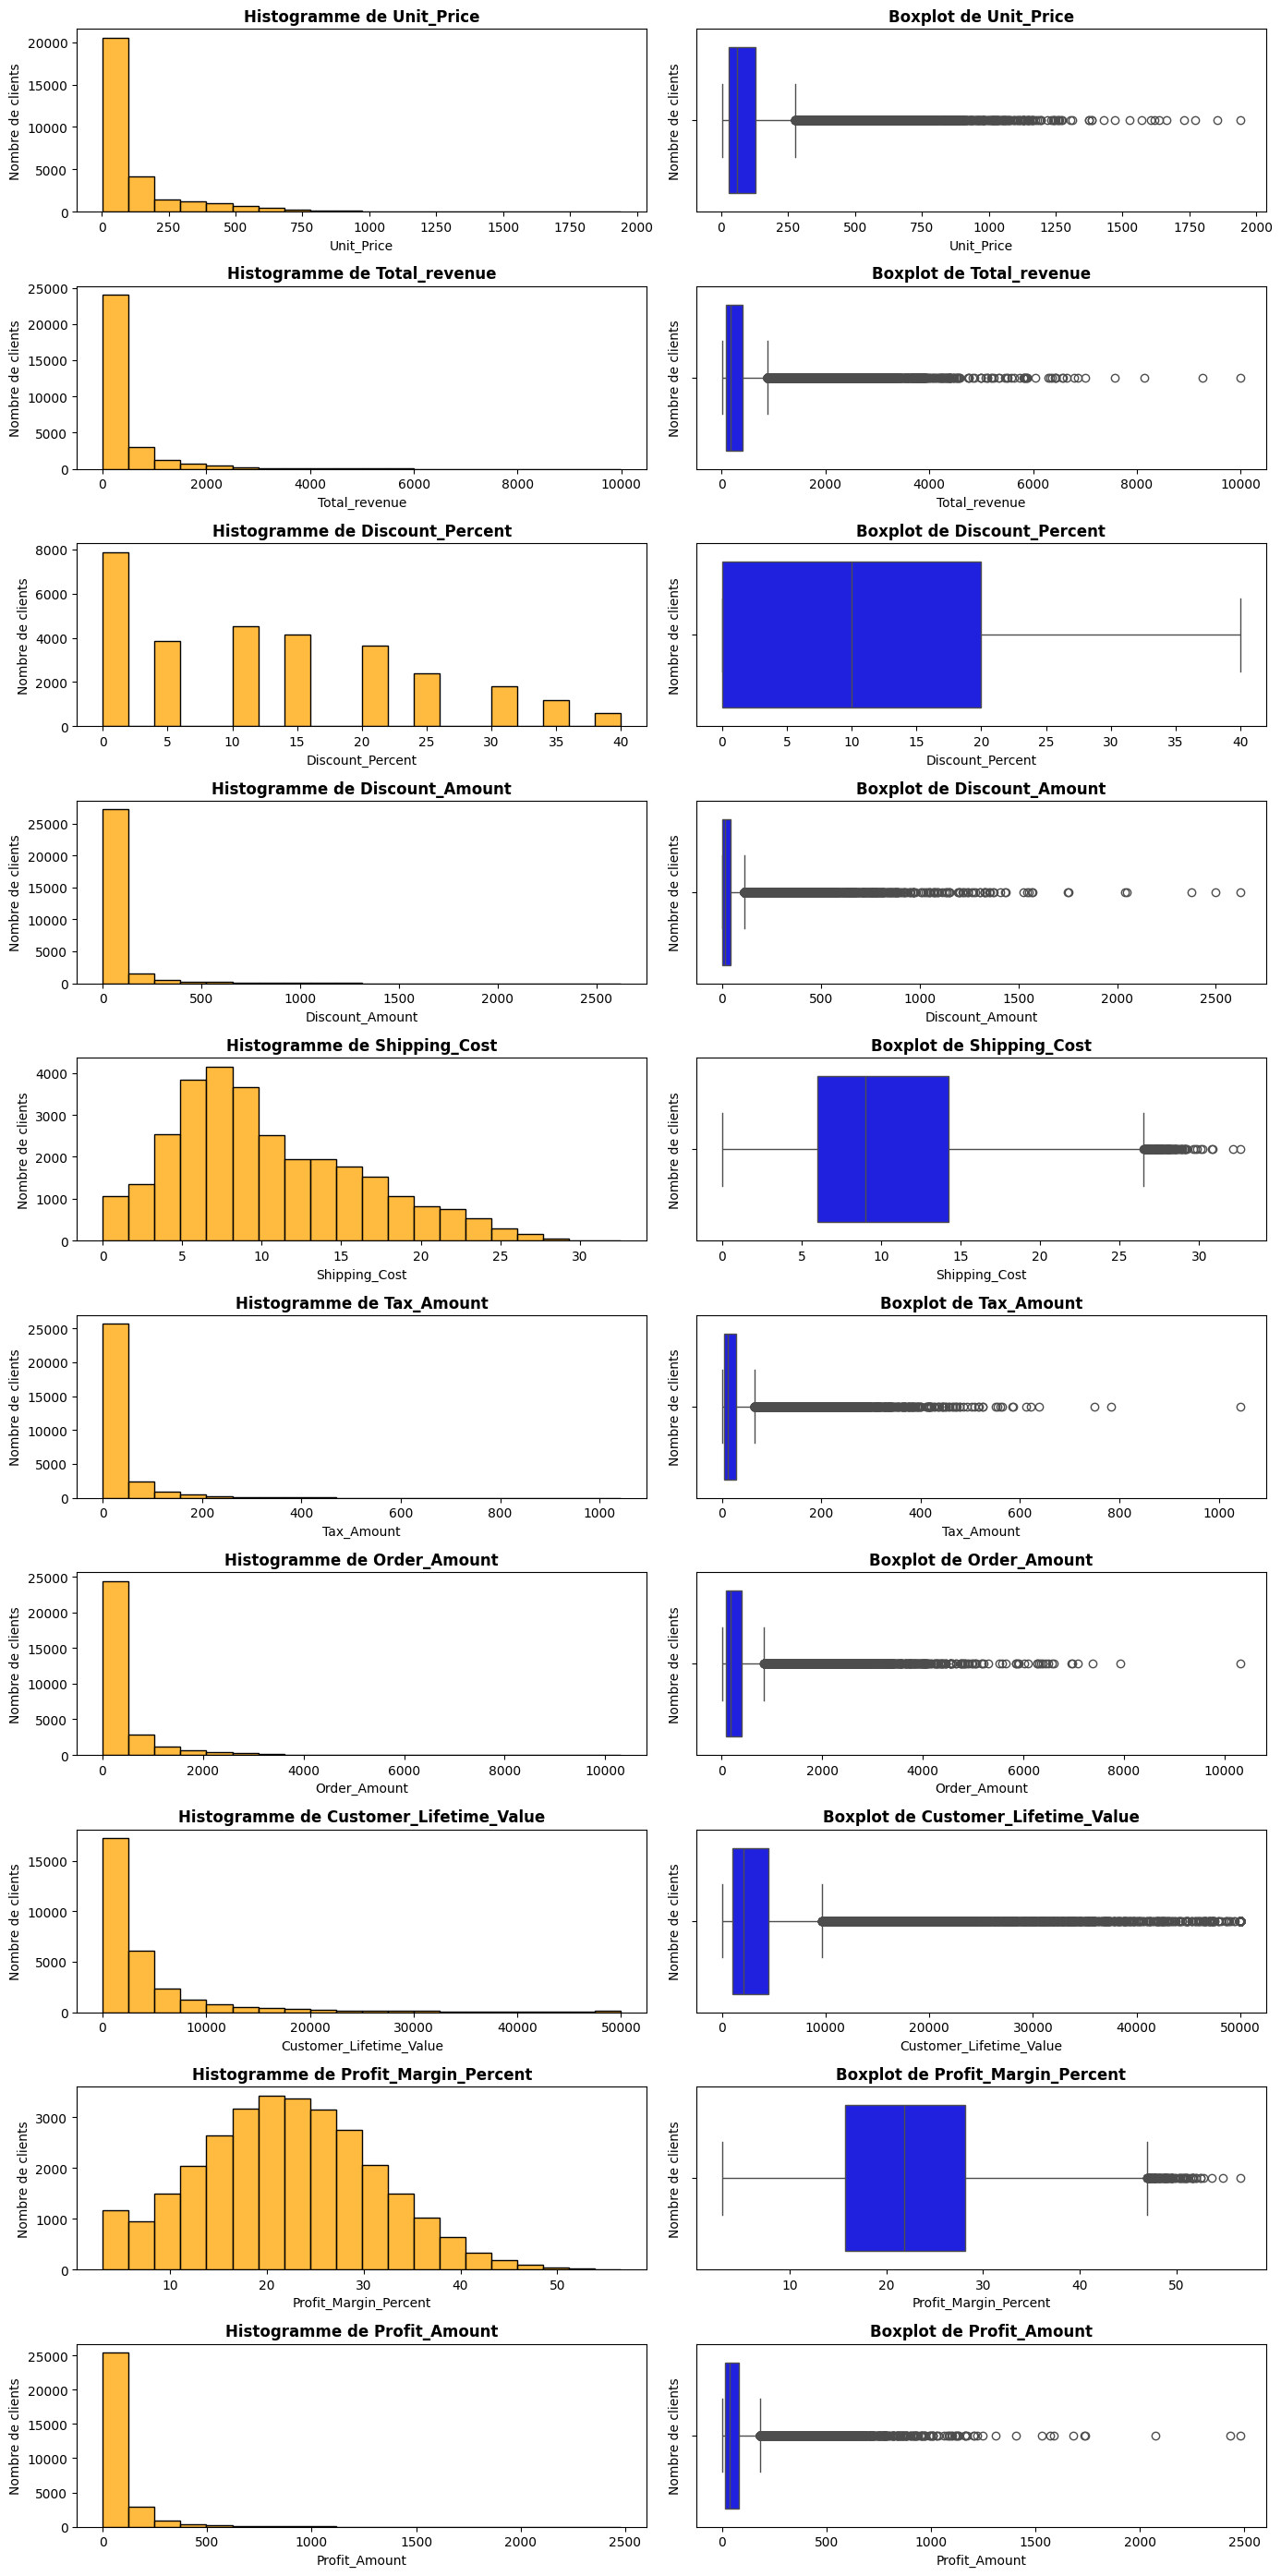

In [15]:
plt.figure(figsize=(14,  7*4))
i= 0
for num in df_num[var_contenue]:

    # Histogrammes
    plt.subplot(10, 2, 2*i + 1)
    sns.histplot(df[num], bins=20, color='orange')
    plt.title(f'Histogramme de {num}', fontsize=12, fontweight='bold')
    plt.xlabel(num)
    plt.ylabel('Nombre de clients')

    # boxplots
    plt.subplot(10, 2, 2*i+2)
    sns.boxplot(x=df[num], color='blue')
    plt.title(f'Boxplot de {num}', fontsize=12, fontweight='bold')
    plt.xlabel(num)
    plt.ylabel('Nombre de clients')
    i += 1
plt.tight_layout()
plt.show()

## Analyse univariée des variable catégorielles

In [16]:
data_cat = {
    "Qualitative":{
        "Nominal":['Customer_Gender', 'Country', 'City', 'Product_Category', 'Product_Subcategory', 'Brand', 'Payment_Method', 'Device_Type',
                  'Traffic_Source','Shipping_Method', 'Warehouse_Region', 'Order_Status', 'Day_Of_Week', 'Season', 'Coupon_Used', 'Returned',
                  'Holiday_Season', 'High_Value_Order'],
        "Ordinal":['Customer_Segment', 'Membership_Status', 'Quarter', 'Review_Rating']
    },
    "Quantitative":{
        "Discrete": ['Customer_Age', 'Quantity', 'Delivery_Days', 'Year', 'Month', 'Day'],
    }
}

In [17]:
nominal_columns = data_cat["Qualitative"]["Nominal"]
df_nominal = df[nominal_columns]

In [18]:
len(data_cat["Qualitative"]["Nominal"])

18

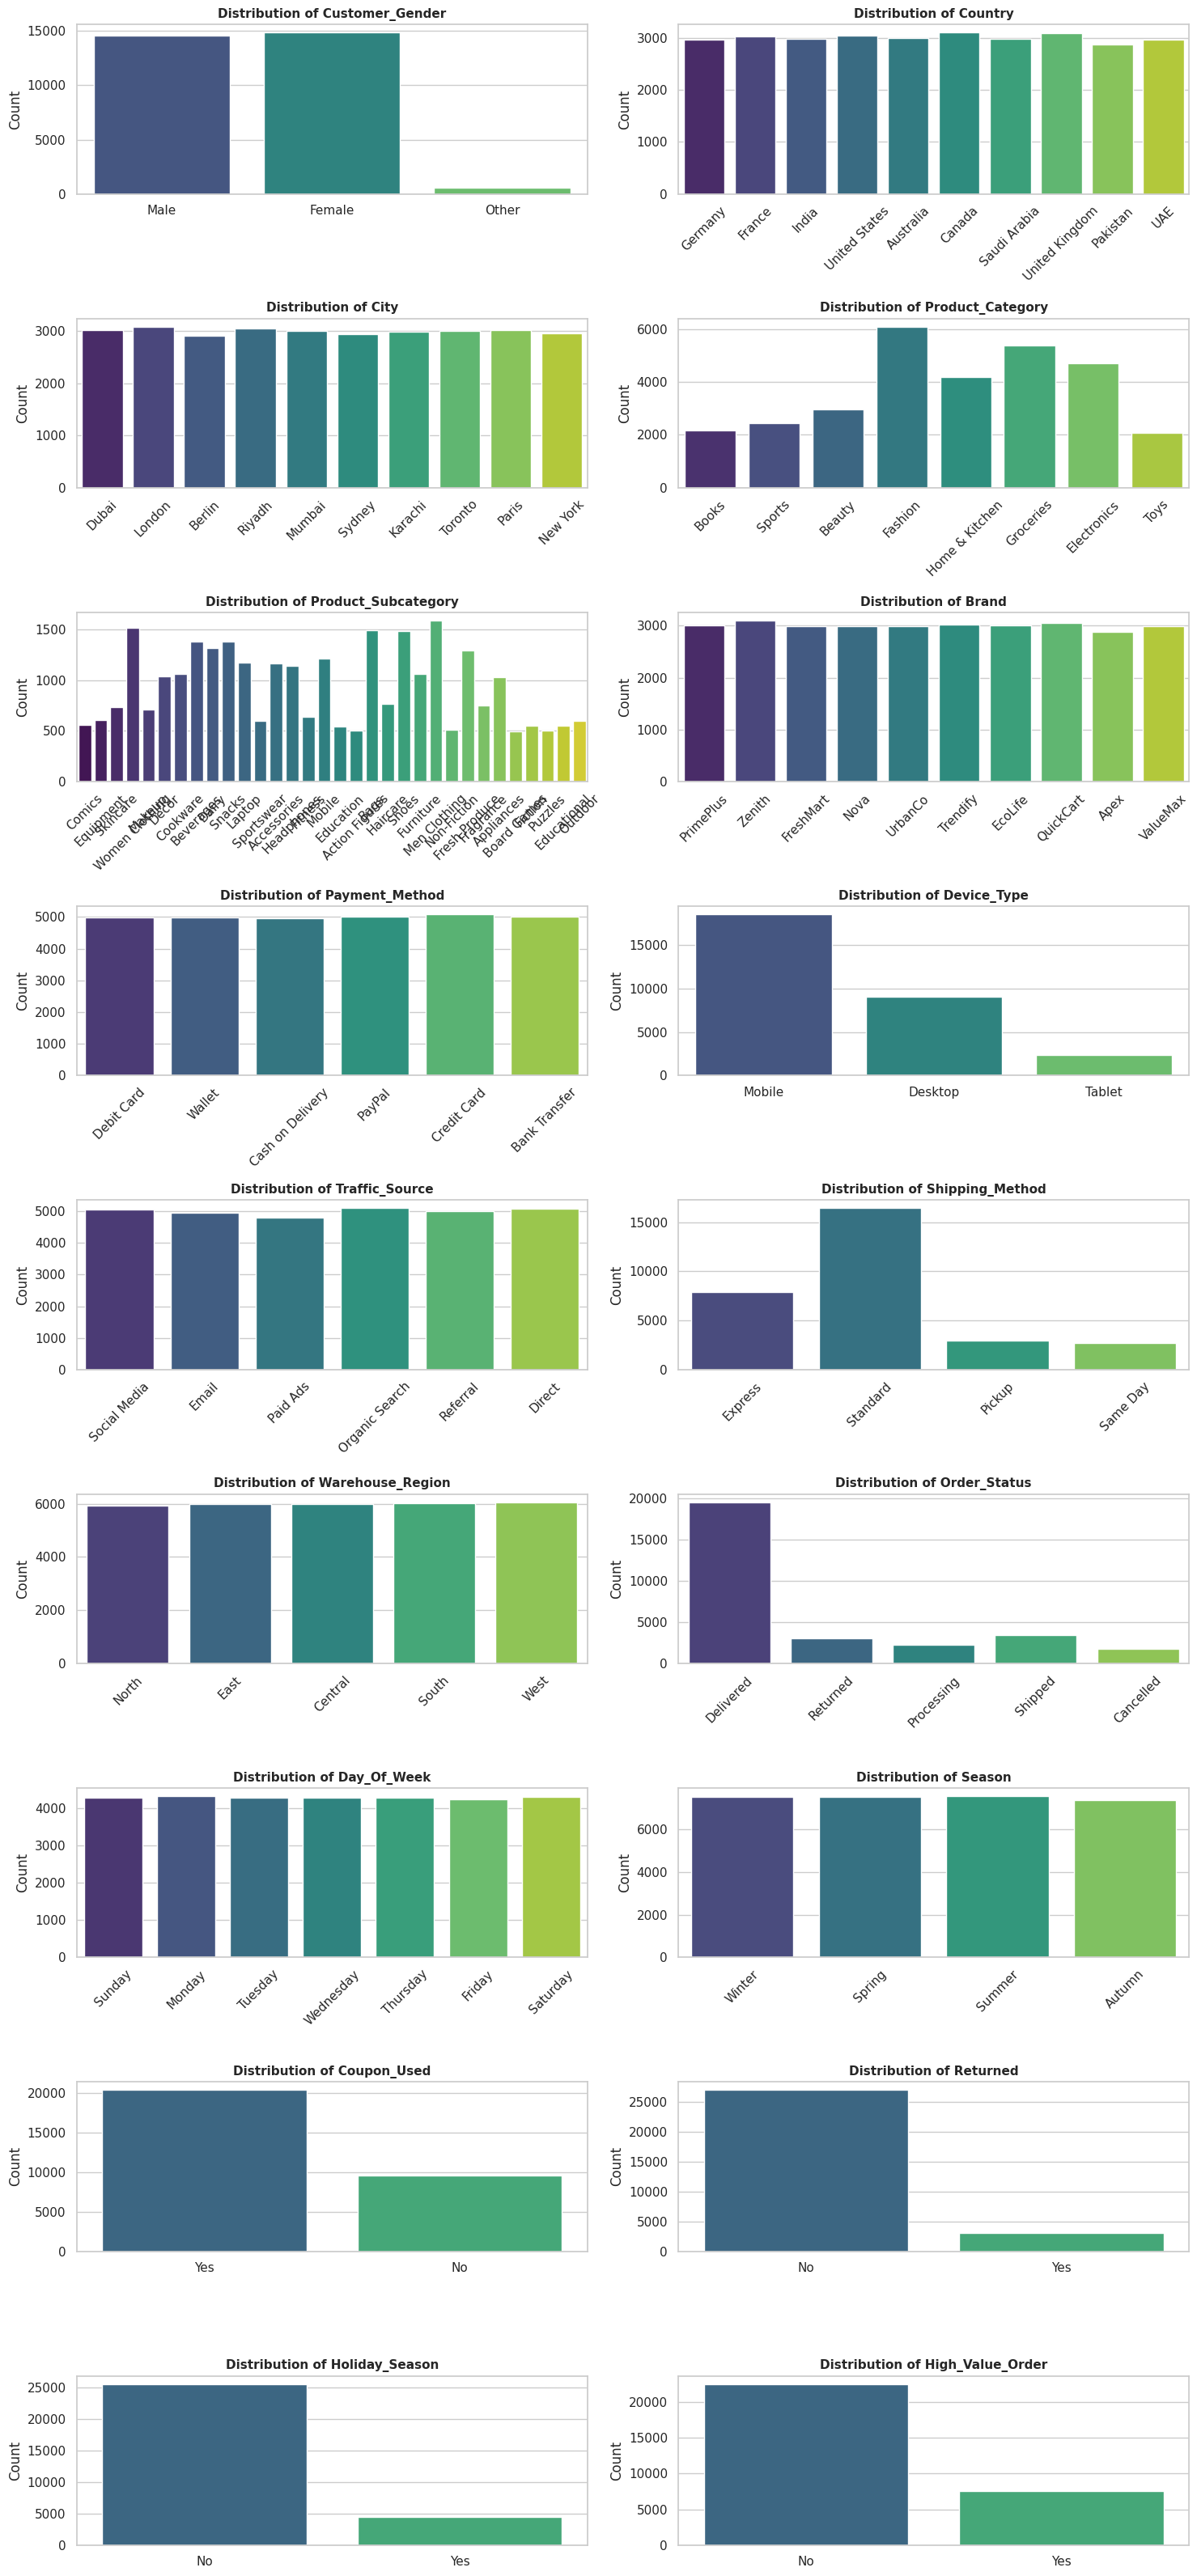

In [19]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(15, 32))
axes = axes.flatten()

for i, col in enumerate(data_cat["Qualitative"]["Nominal"]):
    sns.countplot(data=df_nominal, x=col, ax=axes[i], palette="viridis", hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

    if df_nominal[col].nunique() > 3:
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Analyse de corrélation

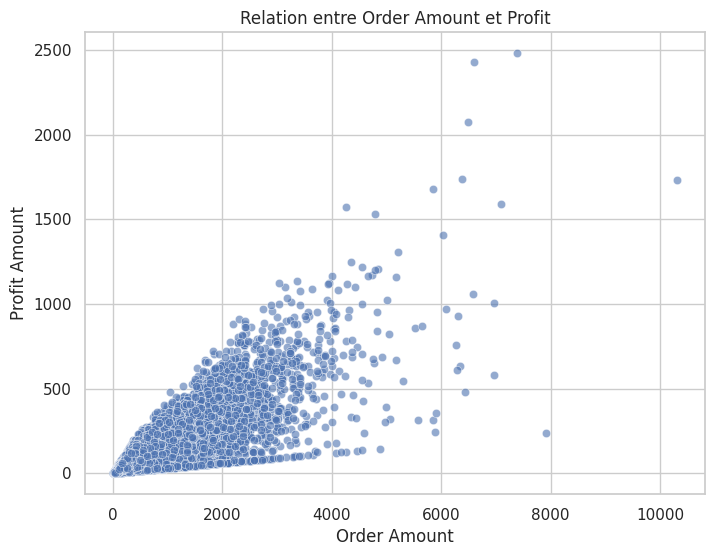

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Order_Amount",
    y="Profit_Amount",
    alpha=0.6
)

plt.title("Relation entre Order Amount et Profit")
plt.xlabel("Order Amount")
plt.ylabel("Profit Amount")

plt.show()

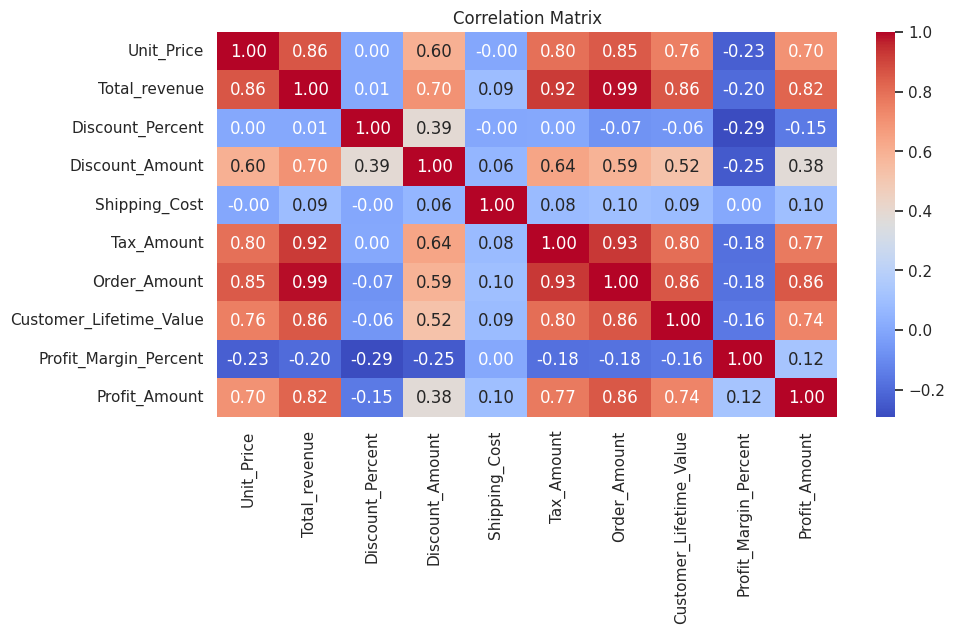

In [24]:
col_num = df[var_contenue]

# Correlation matrix
corr = col_num.corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 💰 Corrélations avec les ventes
- Très forte corrélation entre **Order_Amount** et **Total_revenue (0.99)**
- Forte relation avec **Tax_Amount (0.93)** et **Profit_Amount (0.86)**

👉 Le chiffre d’affaires dépend principalement du prix et du volume des commandes.

---

## 📦 Impact des promotions
- Discount_Amount a un impact positif sur les ventes

👉 Les promotions augmentent le volume des ventes.

---

## 💸 Analyse du profit
- Profit fortement lié aux ventes et au revenu

👉 Plus les ventes augmentent, plus le profit augmente.

---

## ⚠️ Impact des réductions
- Discount_Percent est négativement corrélé avec la marge de profit

👉 Les réductions réduisent la rentabilité.

---

## 👥 Clients
- Les clients à forte valeur génèrent plus de revenus et de profit

👉 Le CLV est un indicateur clé de rentabilité.

# Test d'epothese

In [25]:
# T-Test:
from scipy import stats

group1 = df[df['Coupon_Used'] == 'Yes']['Profit_Amount']
group2 = df[df['Coupon_Used'] == 'No']['Profit_Amount']

t_stat, p_value = stats.ttest_ind(group1, group2)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -19.584314759956435
P-value: 7.141316241645397e-85


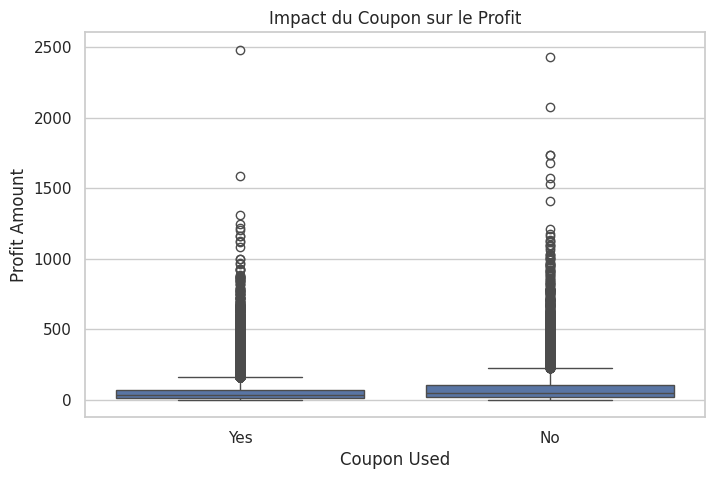

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Coupon_Used', y='Profit_Amount', data=df)

plt.title("Impact du Coupon sur le Profit")
plt.xlabel("Coupon Used")
plt.ylabel("Profit Amount")

plt.show()

Le test T de Student a été utilisé pour comparer le profit moyen entre deux groupes :
- Les clients ayant utilisé un coupon
- Les clients n’ayant pas utilisé de coupon.

Les résultats montrent une p-value extrêmement faible (p < 0.05), ce qui signifie que la différence est statistiquement significative.

**Conclusion :**

L’utilisation des coupons a un impact significatif sur le profit.
Le groupe ayant utilisé des coupons génère un profit moyen différent de celui qui n’en utilise pas.

Le T-stat négatif indique que le profit moyen des clients utilisant des coupons est inférieur à celui des autres clients.

In [26]:
# Chi-Square Test:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Payment_Method'], df['Order_Status'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("P-value:", p)

Chi2: 19.028413954211498
P-value: 0.5199797756603575


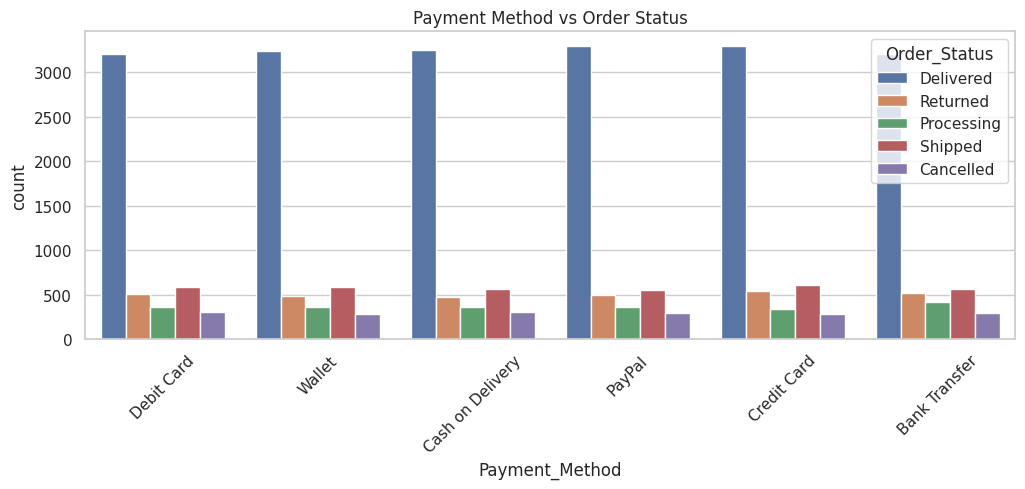

In [36]:

plt.figure(figsize=(12,4))

sns.countplot(x='Payment_Method', hue='Order_Status', data=df)

plt.title("Payment Method vs Order Status")
plt.xticks(rotation=45)

plt.show()

Le test du Chi-square a été utilisé pour analyser la relation entre :
- Le mode de paiement
- Le statut de commande

La p-value obtenue est supérieure à 0.05 (p = 0.52), ce qui signifie que le résultat n’est pas statistiquement significatif.

**Conclusion :**

Il n’existe pas de relation significative entre le mode de paiement et le statut de commande.

In [27]:
# ANOVA Test:
groups = [df[df['Product_Category'] == cat]['Profit_Amount']
          for cat in df['Product_Category'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print("F-stat:", f_stat)
print("P-value:", p_value)

F-stat: 2389.523112340888
P-value: 0.0


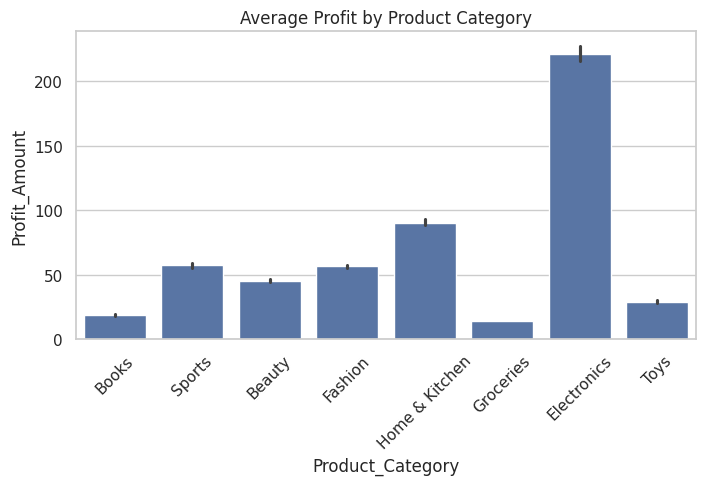

In [33]:
plt.figure(figsize=(8,4))

sns.barplot(x='Product_Category', y='Profit_Amount', data=df, estimator='mean')

plt.title("Average Profit by Product Category")
plt.xticks(rotation=45)

plt.show()

Le test ANOVA a été appliqué pour comparer le profit moyen entre différentes catégories de produits.

La p-value est égale à 0.0, ce qui indique une différence statistiquement très significative entre les groupes.

**Conclusion :**
Le profit varie fortement selon la catégorie de produit.
Toutes les catégories ne contribuent pas de la même manière à la rentabilité.